In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [4]:

v2 = pd.read_csv("pycrac_2.0.0/tests/timings.tsv", sep="\t")
v1 = pd.read_csv("pycrac_test/pycrac/tests/timings.tsv", sep="\t") 
print(v1)
print(v2)

                                                 test  \
0                     demultiplexing illumina indexes   
1   demultiplexing illumina indexes on compressed ...   
2        demultiplexing random barcodes in 5' adapter   
3   demultiplexing random barcodes in 5' adapter o...   
4                        range 300 and deletions only   
5    same as above but counting hits for introns only   
6   same as above but now counting hits in exons only   
7                                 # pyClusterReads...   
8   counting overlap between clusters and genomic ...   
9                                  with range setting   
10                   with annotation = protein_coding   
11                   with annotation = protein_coding   
12                               with all annotations   
13                             with --binoverlap flag   
14                              with --outputall flag   
15                                    with genes list   
16          with genes list and

In [10]:
labels = [
    "pyNormalizeIntervalLengths --fixed 20",
    "pyNormalizeIntervalLengths --min 20",
    "pyNormalizeIntervalLengths --addboth 20",
    "pyNormalizeIntervalLengths --addleft 20",
    "pyNormalizeIntervalLengths --addright 20",
]
m1 = v1["script"].eq("pyNormalizeIntervalLengths.py")
m2 = v2["script"].eq("pyNormalizeIntervalLengths.py")

v1.loc[m1, "test"] = labels
v2.loc[m2, "test"] = labels

In [11]:
df = v1.merge(
    v2,
    on=["script", "test"],
    how="outer",
    suffixes=("_v1", "_v2"))

df = df.dropna(axis=0)
df["test"] = df["test"].str.replace(r"[#\.]", "", regex=True)
df["test"] = df["test"].str.replace(r"py$", "", regex=True)
df.to_csv("test1_timings.tsv", sep="\t")
df_plot_list = ["pyFastqJoiner.py",
"pyFastqDuplicateRemover.py",
"pyReadCounters.py",
"pyPileup.py",
"pyReadAligner.py",
"pyClusterReads.py",
"pyCalculateFDRs.py",
"pyGTF2bedGraph.py",
"pyGTF2sgr.py",
"pyFilterGTF.py",
"pyMotif.py",
"pyBinCollector.py",
"pyCalculateMutationFrequencies.py",
"pyNormalizeIntervalLengths.py",
"pyFastqSplitter.py"]
df = df[df["script"].isin(df_plot_list)]

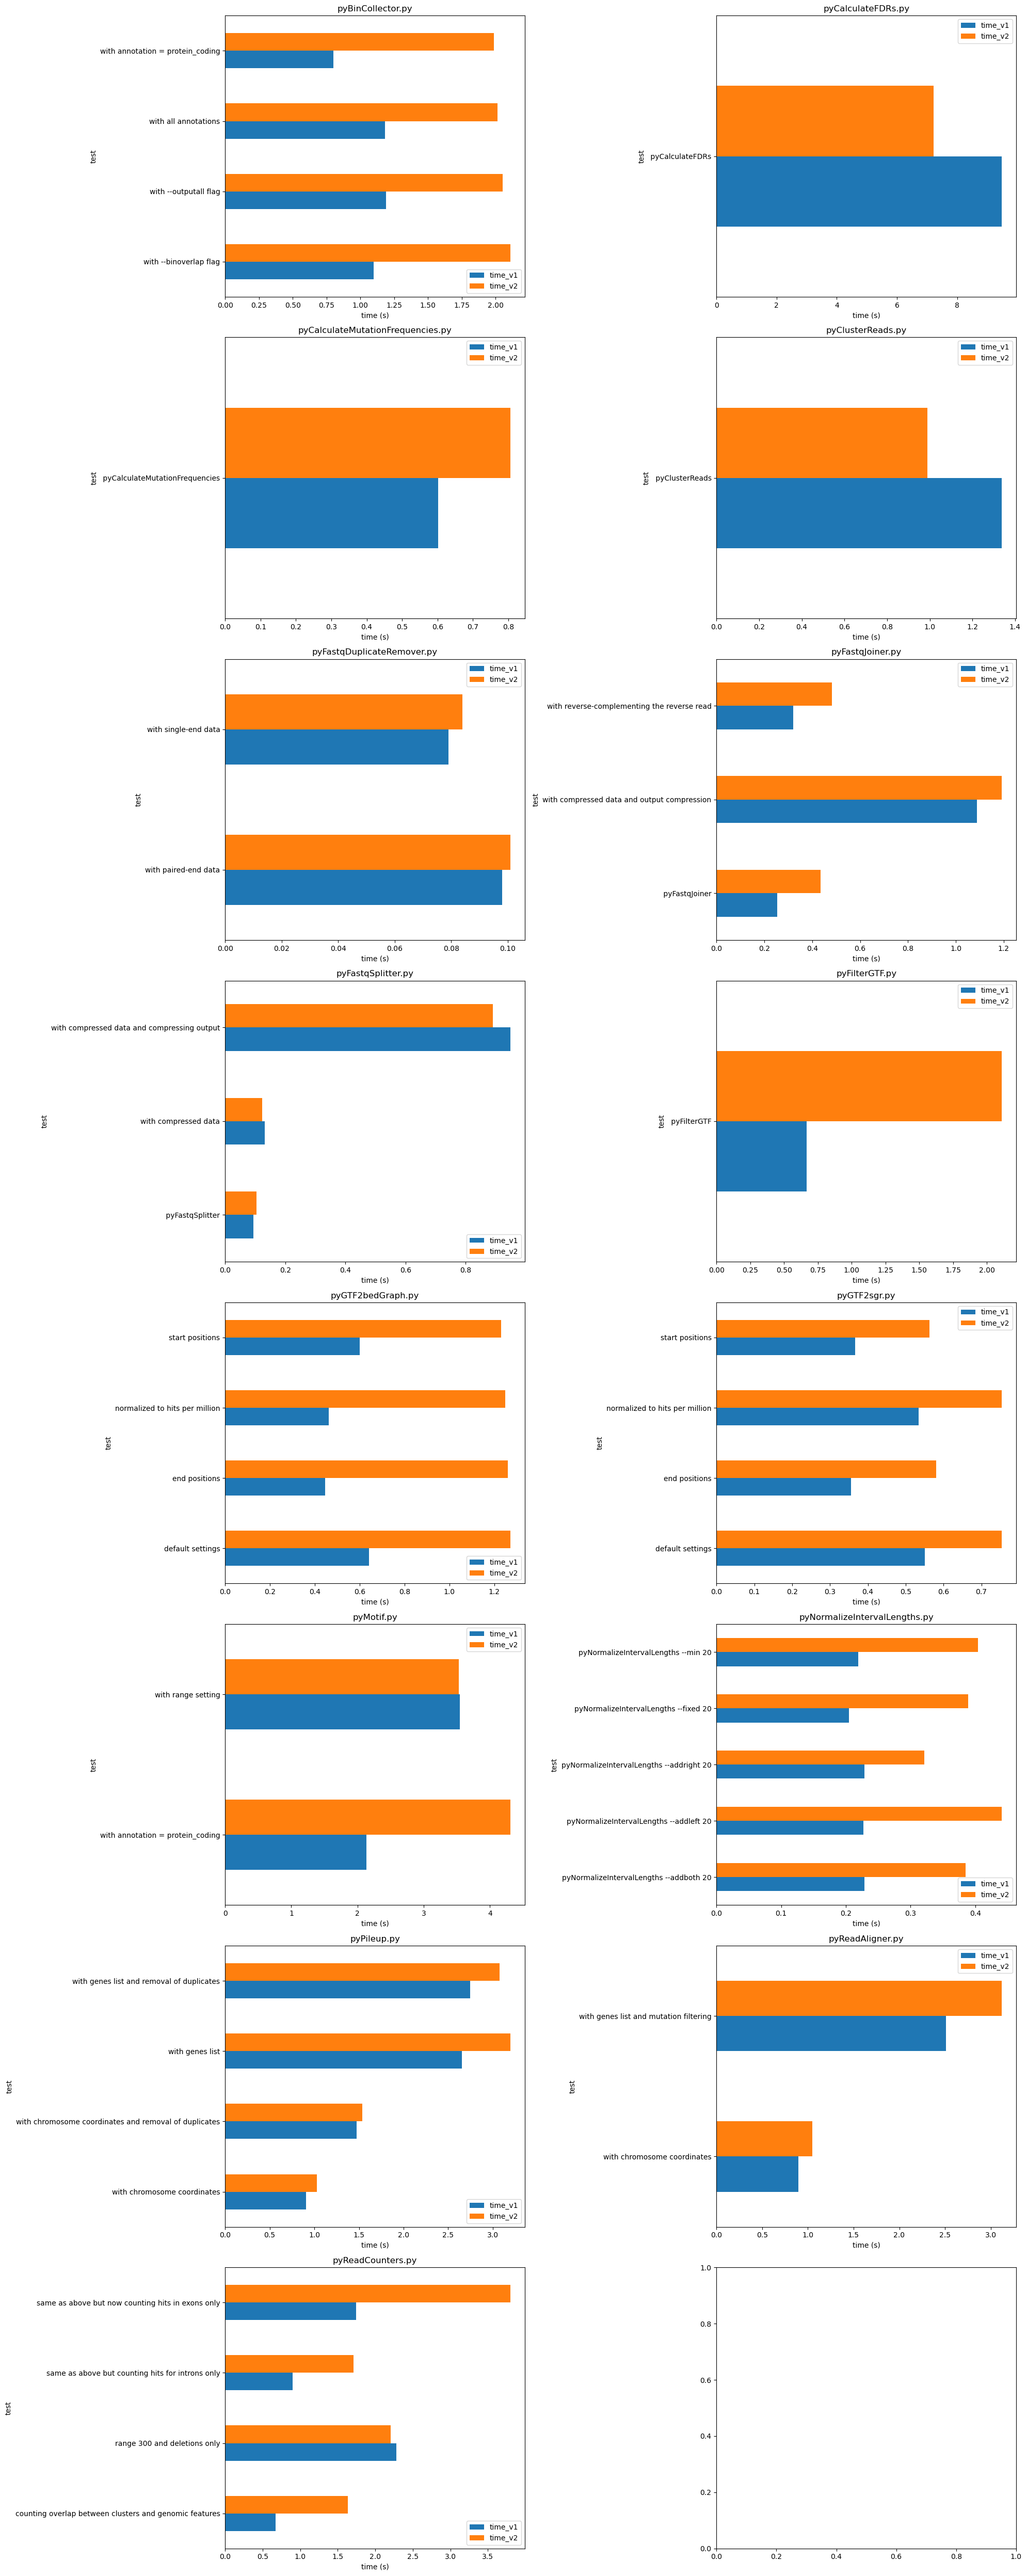

In [17]:
fig, ax = plt.subplots(8, 2, figsize=(20, 50))
ax = ax.ravel()
scripts={}
for i, (script, subplt) in enumerate(df.groupby("script")): #time bar plot
    subplt.plot(
        x= "test",
        y=["time_v1", "time_v2"],
        kind="barh",
        ax=ax[i]
    )
    ax[i].set_title(script)
    ax[i].set_xlabel("time (s)")
    #fold change calculation
    ave_fc = subplt["time_v1"].mean()/subplt["time_v2"].mean()
    if script not in scripts: 
        scripts[script] = ave_fc
plt.tight_layout()
plt.savefig("pycrac_1v2_plot.pdf")
plt.show()

pyBinCollector.py 0.5230920004900159
pyCalculateFDRs.py 1.3143530063729565
pyCalculateMutationFrequencies.py 0.7468982630272952
pyClusterReads.py 1.352881698685541
pyFastqDuplicateRemover.py 0.9567567567567568
pyFastqJoiner.py 0.7875770507349457
pyFastqSplitter.py 1.0509838998211092
pyFilterGTF.py 0.31549028896257697
pyGTF2bedGraph.py 0.42934131736526954
pyGTF2sgr.py 0.6816295737457564
pyMotif.py 0.7244676781843683
pyNormalizeIntervalLengths.py 0.5716494845360824
pyPileup.py 0.8801040606266259
pyReadAligner.py 0.8174184261036468
pyReadCounters.py 0.5983527650016045


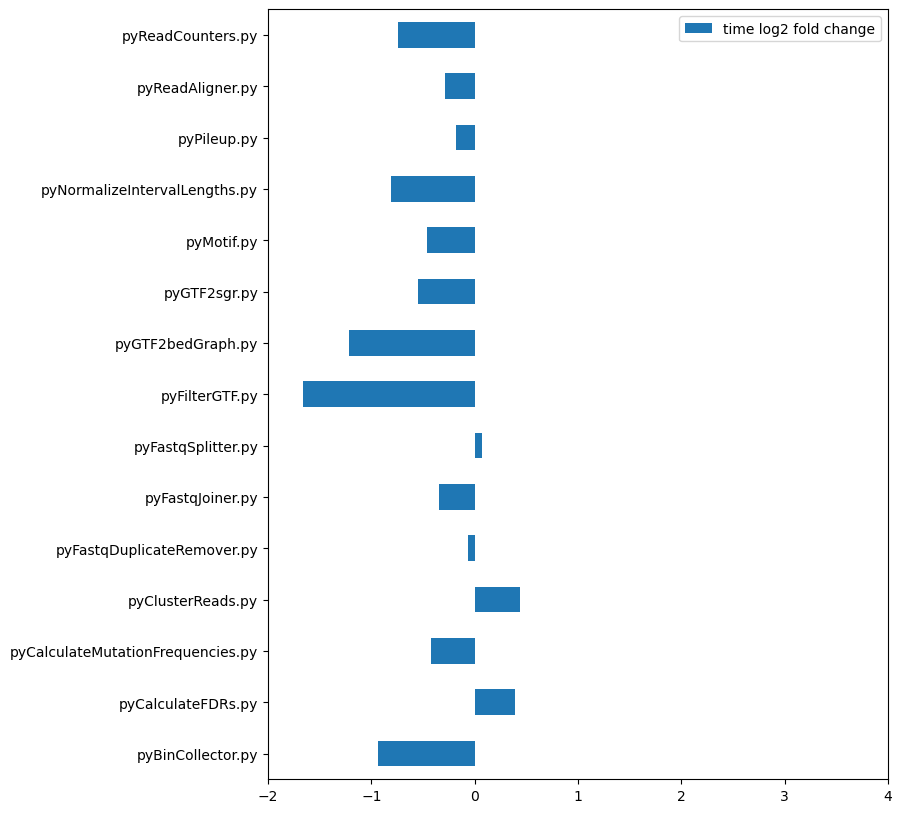

In [16]:
for key, value in scripts.items():
    print(key, value)

df_fc = pd.DataFrame([scripts])

df_fc = np.log2(df_fc.T)
df_fc = df_fc.rename(columns={0:"time log2 fold change"})

ax = df_fc.plot(
    kind="barh",
    figsize=(8, 10)
)
ax.set_xlim(-2, 4)
plt.savefig("pycrac_1v2_lfc_plot.pdf")
plt.show()


In [7]:
!jupyter nbconvert --to python plot.ipynb

[NbConvertApp] Converting notebook plot.ipynb to python
[NbConvertApp] Writing 1942 bytes to plot.py
